In [18]:
import numpy as np
import pandas as pd
import torch
import scipy
from scipy import signal # Explicitly import signal for EMG filtering
from torch.utils.data import TensorDataset as TData
from torch.utils.data import DataLoader as DL
import matplotlib.pyplot as plt

# --- NEW IMPORTS FOR YOUR EMG PIPELINE ---
import glob  # Crucial for reading the list of 72+ CSV files in the Kaggle dataset
import os

# These are specific to the 2014 Paper (SVM Approach)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
# --- CONFIGURATION FOR EMG PIPELINE ---

# Hardware Specs (Myo Armband)
SAMPLING_RATE = 200  # Hz (This is fixed for the Kaggle dataset)
NUM_CHANNELS = 8     # The Myo has 8 sensors

# Windowing Parameters (Crucial for the 2014 Paper approach)
# The paper analyzes "windows" of time, not single points.
# 200ms window is standard for gesture recognition.
WINDOW_MS = 200
WINDOW_SIZE = int(SAMPLING_RATE * (WINDOW_MS / 1000)) # = 40 samples

# Overlap (Sliding window)
# We slide the window forward by 50ms at a time (75% overlap)
STRIDE_MS = 50
STRIDE_SIZE = int(SAMPLING_RATE * (STRIDE_MS / 1000)) # = 10 samples

print(f"Configuration Set:")
print(f"Sampling Rate: {SAMPLING_RATE} Hz")
print(f"Window Size: {WINDOW_SIZE} rows ({WINDOW_MS} ms)")
print(f"Step Size: {STRIDE_SIZE} rows ({STRIDE_MS} ms)")

Configuration Set:
Sampling Rate: 200 Hz
Window Size: 40 rows (200 ms)
Step Size: 10 rows (50 ms)


In [20]:
import pandas as pd
import os
import glob
import zipfile
import tkinter as tk
from tkinter import filedialog

# --- 1. UPLOAD (local file picker instead of Colab) ---
print("Step 1: Select the zip file (or the csv directly) from Kaggle")
root = tk.Tk()
root.withdraw()
selected_path = filedialog.askopenfilename(
    filetypes=[("Zip or CSV files", "*.zip *.csv")]
)
filename = os.path.basename(selected_path)
source_dir = os.path.dirname(selected_path)

# --- 2. UNZIP (if necessary) ---
if filename.endswith('.zip'):
    print(f"Unzipping {filename}...")
    extract_dir = os.path.join(source_dir, "extracted")
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(selected_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    csv_files = glob.glob(os.path.join(extract_dir, "*.csv"))
    if len(csv_files) == 0:
        raise ValueError("No CSV found in the zip file!")
    target_file = csv_files[0]
else:
    target_file = selected_path

print(f"Loading data from: {target_file}")

# --- 3. LOAD DATA ---
df = pd.read_csv(target_file)

# --- 4. INSPECT ---
print("\n--- Data Loaded Successfully ---")
print(f"Shape: {df.shape} (Rows, Columns)")
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn Names:")
print(list(df.columns))

Step 1: Select the zip file (or the csv directly) from Kaggle
Unzipping archive (3).zip...
Loading data from: C:/Users/hi2ad/Downloads\extracted\EMG-data.csv

--- Data Loaded Successfully ---
Shape: (4237907, 11) (Rows, Columns)

First 5 rows:
   time  channel1  channel2  channel3  channel4  channel5  channel6  channel7  \
0     1   0.00001  -0.00002  -0.00001  -0.00003   0.00000  -0.00001   0.00000   
1     5   0.00001  -0.00002  -0.00001  -0.00003   0.00000  -0.00001   0.00000   
2     6  -0.00001   0.00001   0.00002   0.00000   0.00001  -0.00002  -0.00001   
3     7  -0.00001   0.00001   0.00002   0.00000   0.00001  -0.00002  -0.00001   
4     8  -0.00001   0.00001   0.00002   0.00000   0.00001  -0.00002  -0.00001   

   channel8  class  label  
0  -0.00001      0      1  
1  -0.00001      0      1  
2   0.00001      0      1  
3   0.00001      0      1  
4   0.00001      0      1  

Column Names:
['time', 'channel1', 'channel2', 'channel3', 'channel4', 'channel5', 'channel6', 'chan

In [21]:
from scipy import signal

# --- 1. CONFIGURATION ---
LOW_CUT = 5.0   # Hz
HIGH_CUT = 95.0 # Hz (Must be < SAMPLING_RATE / 2)
ORDER = 4       # Steepness of the filter

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    y = signal.filtfilt(b, a, data)
    return y

def notch_filter(data, cutoff, fs, Q=30):
    nyq = 0.5 * fs
    freq = cutoff / nyq
    b, a = signal.iirnotch(freq, Q)
    y = signal.filtfilt(b, a, data)
    return y

# --- 2. APPLY FILTERS ---
print("Applying Filters to Raw Data...")

# List of channel names
channels = ['channel1', 'channel2', 'channel3', 'channel4',
            'channel5', 'channel6', 'channel7', 'channel8']

# Create a copy so we don't overwrite the original if we need to debug
df_filtered = df.copy()

for col in channels:
    # 1. Apply Bandpass (Remove motion noise & high freq noise)
    raw_sig = df[col].values
    bandpassed = butter_bandpass_filter(raw_sig, LOW_CUT, HIGH_CUT, SAMPLING_RATE, ORDER)

    # 2. Apply Notch (Remove 50Hz power line hum - Optional but recommended)
    # If the data looks "clean" you might skip this, but it's safe to keep.
    filtered = notch_filter(bandpassed, 50.0, SAMPLING_RATE)

    df_filtered[col] = filtered

print("Done. Replaced raw signals with filtered signals.")
print(df_filtered[channels].head())

Applying Filters to Raw Data...
Done. Replaced raw signals with filtered signals.
       channel1      channel2      channel3  channel4      channel5  \
0  4.871572e-07  5.352476e-07 -2.792095e-07  0.000001 -3.912535e-07   
1  2.385444e-06 -3.014628e-07  1.208054e-06  0.000002  2.546308e-07   
2 -1.509011e-05  2.645651e-05  3.209271e-05  0.000031  1.145652e-05   
3 -1.282759e-05  2.291702e-05  2.996737e-05  0.000029  1.114543e-05   
4 -1.048247e-05  2.274287e-05  3.129049e-05  0.000028  1.143834e-05   

       channel6      channel7      channel8  
0 -3.075985e-07 -1.008392e-06 -1.521273e-07  
1  2.201446e-07  9.276888e-07 -9.191633e-07  
2 -7.375784e-06 -7.709837e-06  1.886595e-05  
3 -5.678519e-06 -6.429094e-06  1.718467e-05  
4 -6.014343e-06 -5.359570e-06  1.630502e-05  


In [22]:
import numpy as np
from scipy.stats import mode

# --- 1. DEFINE COLUMNS ---
SENSOR_COLS = ['channel1', 'channel2', 'channel3', 'channel4',
               'channel5', 'channel6', 'channel7', 'channel8']
TARGET_COL = 'class'  # We use the numeric class ID

# --- 2. DEFINE FEATURE FUNCTIONS ---
def get_features(window_data):
    """
    Calculates 4 Time-Domain features for each of the 8 channels.
    Input: (Window_Size, 8)
    Output: (32,) vector -> [MAV1..8, RMS1..8, WL1..8, ZC1..8]
    """
    feats = []

    # Iterate over each sensor channel
    for col in SENSOR_COLS:
        sig = window_data[col].values

        # 1. Mean Absolute Value (MAV)
        mav = np.mean(np.abs(sig))

        # 2. Root Mean Square (RMS)
        rms = np.sqrt(np.mean(sig**2))

        # 3. Waveform Length (WL)
        # Cumulative length of the waveform over the time segment
        wl = np.sum(np.abs(np.diff(sig)))

        # 4. Zero Crossings (ZC)
        # Number of times the signal crosses the zero axis
        zc = np.sum(np.abs(np.diff(np.sign(sig))) > 0)

        feats.extend([mav, rms, wl, zc])

    return np.array(feats)

# --- 3. APPLY WINDOWING & EXTRACTION ---
print("Starting Feature Extraction (this may take a moment)...")

X_list = []
y_list = []

# Loop through the data with a sliding window
# We stop early so we don't run off the end of the dataframe
num_windows = (len(df) - WINDOW_SIZE) // STRIDE_SIZE

for i in range(0, len(df) - WINDOW_SIZE, STRIDE_SIZE):
    # Slice the window
    window = df_filtered.iloc[i : i + WINDOW_SIZE]

    # Get the label for this window
    # We take the most common class in this window (mode)
    labels = window[TARGET_COL].values
    window_label = mode(labels, keepdims=True)[0][0]

    # OPTIONAL: Filter out Class 0 if it is "unmarked" or "transition" data
    # In many Myo datasets, 0 = undefined movement.
    # If your accuracy is low, uncomment the next two lines:
    if window_label == 0:
       continue

    # Calculate features
    window_features = get_features(window)

    X_list.append(window_features)
    y_list.append(window_label)

# Convert to Numpy Arrays for Scikit-Learn
X = np.array(X_list)
y = np.array(y_list)

print("\n--- Feature Extraction Complete ---")
print(f"Input Shape (X): {X.shape}")
print(f"Target Shape (y): {y.shape}")
print(f"Example Feature Vector (First Window):\n{X[0]}")

Starting Feature Extraction (this may take a moment)...

--- Feature Extraction Complete ---
Input Shape (X): (151186, 32)
Target Shape (y): (151186,)
Example Feature Vector (First Window):
[1.19644391e-06 1.74934613e-06 4.40954876e-05 6.00000000e+00
 5.15183679e-06 8.44508011e-06 1.16204596e-04 1.50000000e+01
 6.97903772e-06 8.61442994e-06 1.50572717e-04 3.00000000e+00
 8.38724930e-06 9.82433235e-06 1.09618064e-04 5.00000000e+00
 4.93833197e-06 5.95229553e-06 8.95426224e-05 9.00000000e+00
 1.55749404e-06 2.19668557e-06 4.37721465e-05 3.00000000e+00
 1.12269821e-05 1.37152993e-05 1.79554477e-04 2.00000000e+00
 6.00745881e-06 8.04717096e-06 1.07070179e-04 8.00000000e+00]


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. SPLIT DATA ---
# We split the data into Training (80%) and Testing (20%)
# stratify=y ensures we have the same proportion of each gesture in both sets
print("Splitting data into Train and Test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --- 2. SCALE DATA (Crucial for SVM) ---
# The 2014 Paper emphasizes feature scaling.
# SVMs perform poorly if one feature (like MAV) is 0.05 and another (like WL) is 500.
scaler = StandardScaler()

# Fit on training data only to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Set Shape: {X_train_scaled.shape}")
print(f"Test Set Shape: {X_test_scaled.shape}")

Splitting data into Train and Test sets...
Training Set Shape: (120948, 32)
Test Set Shape: (30238, 32)


Training SVM Model (this might take a minute)...
Training Complete.


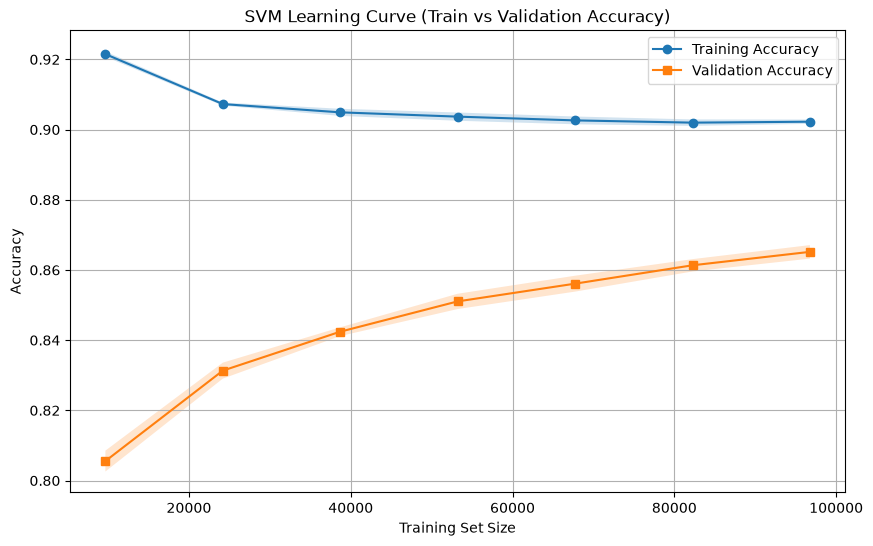


Evaluating on Test Set...
Model Accuracy: 87.50%

Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.97      0.97      4998
           2       0.91      0.90      0.90      4860
           3       0.84      0.86      0.85      4988
           4       0.84      0.87      0.85      5029
           5       0.86      0.85      0.85      5032
           6       0.84      0.82      0.83      5057
           7       0.84      0.59      0.70       274

    accuracy                           0.88     30238
   macro avg       0.87      0.84      0.85     30238
weighted avg       0.87      0.88      0.87     30238



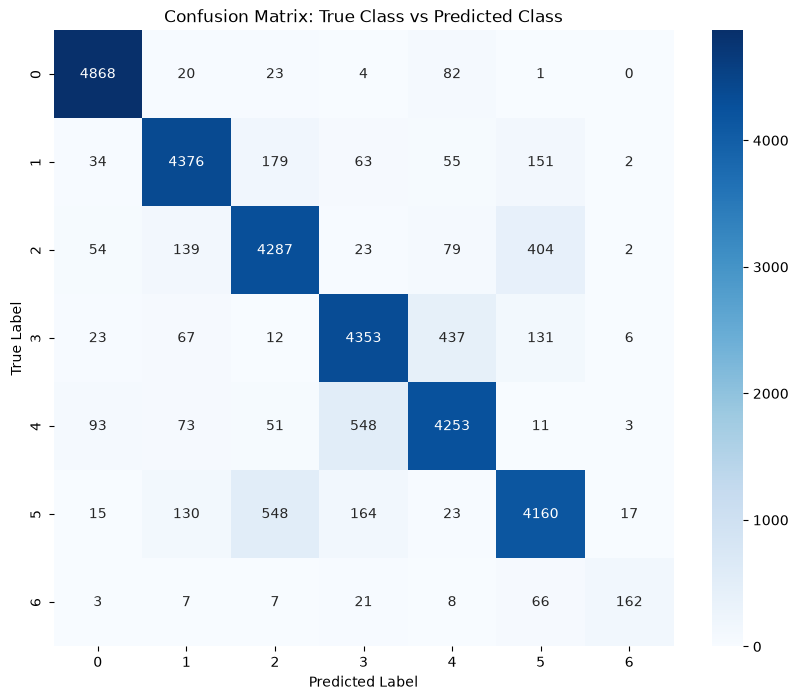

In [24]:
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. DEFINE & TRAIN MODEL ---
print("Training SVM Model (this might take a minute)...")

# We use an RBF Kernel (standard for EMG).
# C=10 allows the model to fit the data tighter than the default C=1.
clf = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)

# Train on the scaled data
clf.fit(X_train_scaled, y_train)

print("Training Complete.")

# --- 2. LEARNING CURVE ---
train_sizes, train_scores, val_scores = learning_curve(
    estimator=clf,
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 7),
    n_jobs=-1
)

# Compute stats
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# --- 3. PLOT ---
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2)

plt.title('SVM Learning Curve (Train vs Validation Accuracy)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

# --- 2. EVALUATE ---
print("\nEvaluating on Test Set...")
y_pred = clf.predict(X_test_scaled)

# Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc*100:.2f}%")

# Print Detailed Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 3. VISUALIZE CONFUSION MATRIX ---
# This shows exactly which gestures are getting confused
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: True Class vs Predicted Class')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [25]:
# Create a dictionary of the average features for each class
# This helps us map the numeric ID to the original string label (if available)

if 'label' in df.columns:
    print("Mapping found:")
    mapping = df[['class', 'label']].drop_duplicates().sort_values('class')
    print(mapping)
else:
    print("No text labels found. We only have numeric classes.")
    print(f"Unique classes: {sorted(df['class'].unique())}")

Mapping found:
         class  label
0            0      1
121170       0      2
257596       0      3
363381       0      4
477579       0      5
...        ...    ...
3934328      6     34
3698427      6     32
3820719      6     33
1219056      7     11
3468079      7     30

[254 rows x 2 columns]


Original samples: 151186
Refined samples:  149818 (Dropped Class 7)
Retraining SVM on refined data...

New Accuracy: 87.85%
              precision    recall  f1-score   support

        Rest       0.96      0.97      0.97      4998
        Fist       0.91      0.90      0.91      4860
     Flexion       0.84      0.86      0.85      4988
   Extension       0.85      0.87      0.86      5029
  Radial Dev       0.86      0.85      0.85      5032
   Ulnar Dev       0.86      0.83      0.84      5057

    accuracy                           0.88     29964
   macro avg       0.88      0.88      0.88     29964
weighted avg       0.88      0.88      0.88     29964



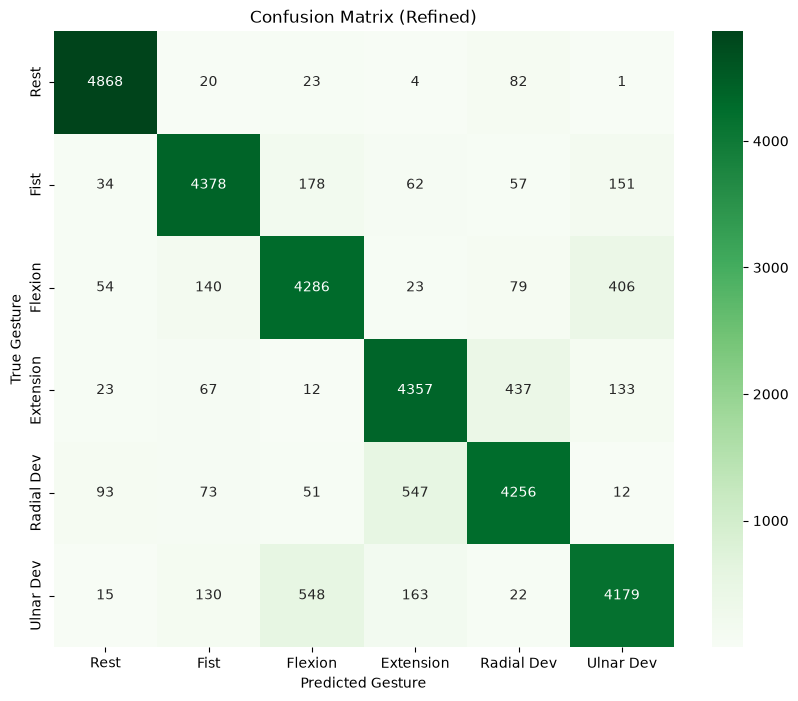

In [26]:
# --- 1. FILTER BAD CLASSES ---
# We keep only classes 1-6.
# Class 0 is "unmarked" and Class 7 is "too small" (only ~270 samples).
valid_classes = [1, 2, 3, 4, 5, 6]

# Create a mask to filter the arrays
mask = np.isin(y, valid_classes)
X_refined = X[mask]
y_refined = y[mask]

print(f"Original samples: {len(y)}")
print(f"Refined samples:  {len(y_refined)} (Dropped Class 7)")

# --- 2. DEFINE THE NAME MAPPING ---
# Based on the Sojan Prajapati Kaggle documentation
gesture_names = {
    1: "Rest",
    2: "Fist",
    3: "Flexion",
    4: "Extension",
    5: "Radial Dev",
    6: "Ulnar Dev"
}

# --- 3. RE-SPLIT AND RE-SCALE ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.2, random_state=42, stratify=y_refined
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 4. RE-TRAIN SVM ---
print("Retraining SVM on refined data...")
clf = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
clf.fit(X_train_scaled, y_train)

# --- 5. REPORT WITH NAMES ---
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"\nNew Accuracy: {acc*100:.2f}%")

# Generate report using the actual names instead of numbers
target_names = [gesture_names[i] for i in sorted(gesture_names.keys())]
print(classification_report(y_test, y_pred, target_names=target_names))

# Plot Matrix with Names
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Refined)')
plt.ylabel('True Gesture')
plt.xlabel('Predicted Gesture')
plt.show()

In [27]:
def get_features(window_data):
    """
    Calculates 5 Time-Domain features for each of the 8 channels.
    Input: (Window_Size, 8)
    Output: (40,) vector -> [MAV, RMS, WL, ZC, SSC for each channel]
    """
    feats = []

    for col in SENSOR_COLS:
        sig = window_data[col].values

        # 1. Mean Absolute Value (MAV)
        mav = np.mean(np.abs(sig))

        # 2. Root Mean Square (RMS)
        rms = np.sqrt(np.mean(sig**2))

        # 3. Waveform Length (WL)
        wl = np.sum(np.abs(np.diff(sig)))

        # 4. Zero Crossings (ZC)
        zc = np.sum(np.abs(np.diff(np.sign(sig))) > 0)

        # 5. Slope Sign Changes (SSC) - NEW!
        # Counts peaks and valleys. We add a tiny threshold to avoid noise.
        # This helps distinguish 'Flexion' from 'Ulnar Dev'
        diff = np.diff(sig)
        ssc = np.sum(np.diff(np.sign(diff)) != 0)

        feats.extend([mav, rms, wl, zc, ssc])

    return np.array(feats)

In [28]:
import numpy as np
from scipy.stats import mode

print("Starting Feature Extraction (including SSC)...")

X_list = []
y_list = []

# Ensure we use the filtered data if available
data_to_use = df_filtered if 'df_filtered' in locals() else df

# Loop through the data
# We assume WINDOW_SIZE and STRIDE_SIZE are still defined from previous cells
for i in range(0, len(data_to_use) - WINDOW_SIZE, STRIDE_SIZE):
    window = data_to_use.iloc[i : i + WINDOW_SIZE]

    # Get the label (most common class in this window)
    labels = window['class'].values
    window_label = mode(labels, keepdims=True)[0][0]

    # Skip 'unmarked' data (Class 0)
    if window_label == 0:
        continue

    # Extract Features (Now returns 40 features)
    feats = get_features(window)

    X_list.append(feats)
    y_list.append(window_label)

# Convert to Numpy Arrays
X = np.array(X_list)
y = np.array(y_list)

print("--- Extraction Complete ---")
print(f"New Input Shape (X): {X.shape}")
# Expecting: (samples, 40)

Starting Feature Extraction (including SSC)...
--- Extraction Complete ---
New Input Shape (X): (151186, 40)


Training on 149818 samples (Class 7 dropped).
Training SVM on 40-feature data...

Final Accuracy: 89.81%
              precision    recall  f1-score   support

        Rest       0.96      0.98      0.97      4998
        Fist       0.93      0.92      0.92      4860
     Flexion       0.87      0.88      0.87      4988
   Extension       0.87      0.89      0.88      5029
  Radial Dev       0.88      0.86      0.87      5032
   Ulnar Dev       0.88      0.86      0.87      5057

    accuracy                           0.90     29964
   macro avg       0.90      0.90      0.90     29964
weighted avg       0.90      0.90      0.90     29964



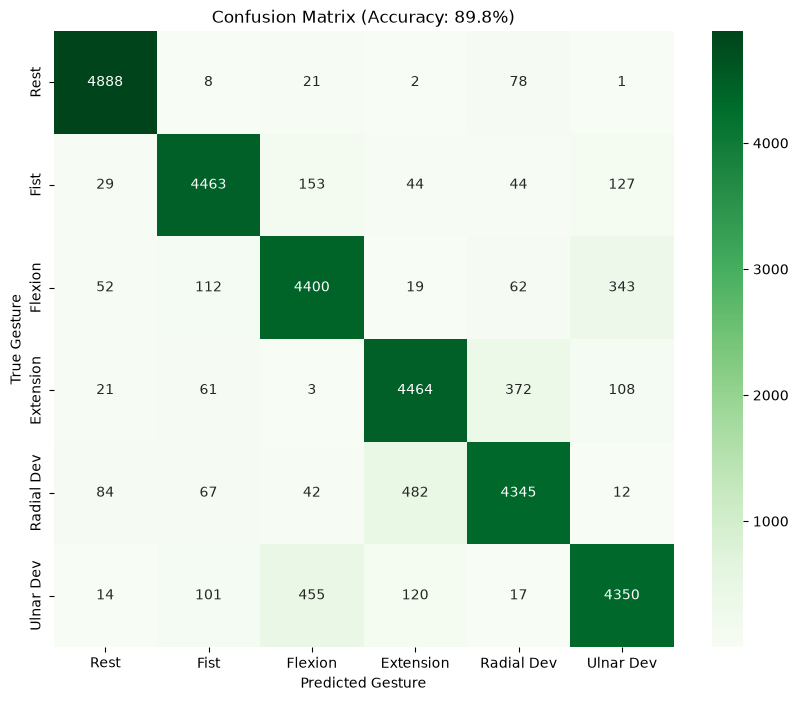

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. FILTER DATA (Drop Class 7) ---
# We keep only classes 1-6 as decided
valid_classes = [1, 2, 3, 4, 5, 6]
mask = np.isin(y, valid_classes)

X_final = X[mask]
y_final = y[mask]

print(f"Training on {len(y_final)} samples (Class 7 dropped).")

# --- 2. DEFINE NAMES ---
gesture_names = {
    1: "Rest",
    2: "Fist",
    3: "Flexion",
    4: "Extension",
    5: "Radial Dev",
    6: "Ulnar Dev"
}
target_names = [gesture_names[i] for i in sorted(gesture_names.keys())]

# --- 3. SPLIT & SCALE ---
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 4. TRAIN SVM ---
print("Training SVM on 40-feature data...")
clf = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
clf.fit(X_train_scaled, y_train)

# --- 5. REPORT RESULTS ---
y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"\nFinal Accuracy: {acc*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=target_names))

# Plot Heatmap
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Confusion Matrix (Accuracy: {acc*100:.1f}%)')
plt.ylabel('True Gesture')
plt.xlabel('Predicted Gesture')
plt.show()

In [30]:
from sklearn.model_selection import GridSearchCV

# --- 1. USE A TINY SUBSET FOR TUNING ---
# We only use the first 5000 samples to find the best settings.
# This makes the grid search 25x faster.
tune_size = 5000
X_tune = X_train_scaled[:tune_size]
y_tune = y_train[:tune_size]

print(f"Tuning parameters on {tune_size} samples...")

# --- 2. DEFINE GRID ---
param_grid = {
    'C': [1, 10, 100],        # Removed 1000 to save time
    'gamma': ['scale', 0.1, 0.01], # Removed 0.001
    'kernel': ['rbf']
}

# --- 3. RUN FAST GRID SEARCH ---
grid = GridSearchCV(SVC(), param_grid, refit=False, verbose=1, cv=3)
grid.fit(X_tune, y_tune)

print(f"\nBest Parameters Found: {grid.best_params_}")

# --- 4. TRAIN FINAL MODEL ON FULL DATA ---
# Now we take the best settings and train ONCE on the full dataset
best_C = grid.best_params_['C']
best_gamma = grid.best_params_['gamma']

print(f"\nTraining Final Model on FULL dataset with C={best_C}, gamma={best_gamma}...")
final_clf = SVC(kernel='rbf', C=best_C, gamma=best_gamma)
final_clf.fit(X_train_scaled, y_train)

# --- 5. REPORT ---
y_pred_tuned = final_clf.predict(X_test_scaled)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Final Tuned Accuracy: {acc_tuned*100:.2f}%")

Tuning parameters on 5000 samples...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best Parameters Found: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Training Final Model on FULL dataset with C=10, gamma=0.01...
Final Tuned Accuracy: 86.43%
